# Replica Plots

Current replica-analysis notebook for the active `Cards/<fit_name>.jl` setup.
It reads `../Fits/replica_refits.csv`, maps `param_i` columns back to card parameter names,
evaluates the replica predictions, and builds data-vs-theory uncertainty bands.


In [1]:
from julia.api import Julia
from julia import Main

import csv
import os
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator, MultipleLocator, NullFormatter
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120


c:\Users\congyue zhang\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fit_name = "BroadBump42LogGaussAlpha1NoLambda2"
replica_results_path = Path("../Fits/replica_data/replica_0324.csv")

data_selections = "by_experiment"  # "by_file" or "by_experiment"
experiments = [
    "ATLAS_7",
    "ATLAS_8",
    "CDF_I",
    "CDF_II",
    "CMS_7",
    "CMS_8",
    "CMS_13",
    "D0_I",
    "D0_II",
    "D0_II_mu",
    "E288",
    "E605",
    "E772",
    "LHCb_7",
    "LHCb_8",
    "LHCb_13",
    "STAR",
]
file_excludes = [
    "E772/E772-5Q6.csv",
    "E772/E772-6Q7.csv",
    "E772/E772-7Q8.csv",
    "E772/E772-8Q9.csv",
]

approximate_total_xsec = True
data_uncertainty_only = False
use_pdf_shift = True
max_replicas = None
band_alpha = 15.865

In [3]:
TMD_fitting_root = Path("../")

def include(name):
    path = (TMD_fitting_root / name).resolve()
    Main.eval(f'include(raw"{path.as_posix()}")')

include(f"Cards/{fit_name}.jl")
include(f"DY/DY_table_{Main.flavor_scheme}.jl")

file_root = Path(f"../Data/{Main.data_name}/Cutted/DY")
matrix_root = Path(f"../Data/{Main.data_name}/Covariance_Matrices/DY")
table_root = Path(f"../Tables/{Main.table_name}/DY")
total_root = Path(f"../Data/DY_total_xsec/{Main.pdf_name}.csv")
error_sets_root = Path(f"../Data/PDF_Matrices/{Main.error_sets_name}/DY")
pdf_diff_root = Path(f"../Data/PDF_Differences/{Main.error_sets_name}")

initial_params = np.asarray(Main.initial_params, dtype=float)

card_path = TMD_fitting_root / "Cards" / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)
param_columns = [f"param_{i}" for i in range(len(param_names))]

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "initial_value": initial_params,
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)
display(param_info_df)


,index,parameter,initial_value,frozen
0,0,lambda1,0.043757,False
1,1,lambda2,0.977418,False
2,2,lambda3,-1.960660,False
3,3,logx0,-4.992170,False
4,4,sigx,0.717326,False
5,5,amp,-0.338498,False
6,6,BNP,1.455523,False
7,7,c0,0.071789,False
8,8,c1,0.025831,False


In [4]:
def to_float64(df):
    num_cols = df.select_dtypes(include=["number"]).columns
    if len(num_cols):
        df[num_cols] = df[num_cols].astype("float64")
    return df

if data_selections == "by_file":
    file_names = []
else:
    file_names = []
    for experiment in experiments:
        exp_dir = file_root / experiment
        for path in sorted(exp_dir.glob("*.csv")):
            rel = f"{experiment}/{path.name}"
            if rel in file_excludes:
                continue
            file_names.append(rel)

print(f"Loaded {len(file_names)} datasets")
display(pd.Series(file_names, name="file"))

data_list = {}
matrix_data_list = {}
matrix_total_list = {}

df_total_xsec = to_float64(pd.read_csv(total_root))
total_xsec_lookup = dict(zip(df_total_xsec["name"], df_total_xsec["total_xsec"]))

for file in tqdm(file_names, desc="Reading data"):
    data_list[file] = to_float64(pd.read_csv(file_root / file))
    matrix_data = to_float64(pd.read_csv(matrix_root / file))
    matrix_data_list[file] = matrix_data

    matrix_pdf_path = error_sets_root / file
    if data_uncertainty_only or (not matrix_pdf_path.exists()):
        matrix_total = matrix_data.copy()
    else:
        matrix_total = matrix_data + to_float64(pd.read_csv(matrix_pdf_path))
    matrix_total_list[file] = matrix_total

    short_name = Path(file).stem
    if short_name in total_xsec_lookup:
        data_list[file]["total_xsec"] = float(total_xsec_lookup[short_name])


Loaded 57 datasets


0       ATLAS_7/ATLAS7-00y10.csv
1       ATLAS_7/ATLAS7-10y20.csv
2       ATLAS_7/ATLAS7-20y24.csv
3       ATLAS_8/ATLAS8-00y04.csv
4       ATLAS_8/ATLAS8-04y08.csv
5       ATLAS_8/ATLAS8-08y12.csv
6     ATLAS_8/ATLAS8-116Q150.csv
7       ATLAS_8/ATLAS8-12y16.csv
8       ATLAS_8/ATLAS8-16y20.csv
9       ATLAS_8/ATLAS8-20y24.csv
10      ATLAS_8/ATLAS8-46Q66.csv
11                CDF_I/CDF1.csv
12               CDF_II/CDF2.csv
13                CMS_7/CMS7.csv
14                CMS_8/CMS8.csv
15        CMS_13/CMS13-00y04.csv
16        CMS_13/CMS13-04y08.csv
17        CMS_13/CMS13-08y12.csv
18      CMS_13/CMS13-106Q170.csv
19        CMS_13/CMS13-12y16.csv
20        CMS_13/CMS13-16y24.csv
21      CMS_13/CMS13-170Q350.csv
22     CMS_13/CMS13-350Q1000.csv
23                  D0_I/D01.csv
24                 D0_II/D02.csv
25            D0_II_mu/D02mu.csv
26         E288/E228-200-4Q5.csv
27         E288/E228-200-5Q6.csv
28         E288/E228-200-6Q7.csv
29         E288/E228-200-7Q8.csv
30        

Reading data: 100%|██████████| 57/57 [00:00<00:00, 242.00it/s]


In [5]:
file_lengths = {file: len(data_list[file]) for file in file_names}

def _norm(path):
    return os.path.normpath(str(path)).replace("\\", "/")

def prediction_reformat(predictions):
    preds = {_norm(k): v for k, v in predictions.items()}
    df_predictions = {}

    for file in file_names:
        n_points = file_lengths[file]
        base = os.path.splitext(file)[0]
        xs = []

        for i in range(n_points):
            candidates = [
                _norm(table_root / f"{base}/{i}.jls"),
                _norm(table_root / f"{base}/{i}.jld2"),
            ]
            for candidate in candidates:
                if candidate in preds:
                    xs.append(preds[candidate])
                    break
            else:
                raise KeyError(f"Missing prediction entry for {file} point {i}")

        xs = np.asarray(xs, dtype=float)
        if approximate_total_xsec and Path(file).stem in total_xsec_lookup and xs.sum() != 0.0:
            data_xsec = data_list[file]["xsec"].to_numpy(dtype=float)
            xs = xs * (data_xsec.sum() / xs.sum())

        df_predictions[file] = xs

    return df_predictions

zero_pdf_shift_list = {
    file: np.zeros(file_lengths[file], dtype=float)
    for file in file_names
}

def _pdf_dataset_key(file):
    return str(Path(file).with_suffix("")).replace("\\", "/")

def load_pdf_shift_replica(path):
    with path.open("rb") as handle:
        pdf_diff_dict = pickle.load(handle)

    pdf_shift_list = {}
    for file in file_names:
        prefix = f"{_pdf_dataset_key(file)}/"
        values = []
        for i in range(file_lengths[file]):
            key = f"{prefix}{i}"
            if key not in pdf_diff_dict:
                raise KeyError(f"Missing PDF-difference entry: {key}")
            values.append(pdf_diff_dict[key])
        pdf_shift_list[file] = np.asarray(values, dtype=float)

    return pdf_shift_list

pdf_shift_replicas = {}
if use_pdf_shift and pdf_diff_root.exists():
    pdf_diff_paths = sorted(pdf_diff_root.glob("*.pkl"), key=lambda path: int(path.stem))
    if pdf_diff_paths:
        pdf_shift_replicas = {
            int(path.stem): load_pdf_shift_replica(path)
            for path in tqdm(pdf_diff_paths, desc="Loading PDF shifts")
        }
        print(f"Loaded {len(pdf_shift_replicas)} PDF-difference replicas from {pdf_diff_root}")
    else:
        print(f"No PDF-difference replicas found under {pdf_diff_root}")
else:
    print("PDF-difference replica shifts are disabled.")

def apply_pdf_shift(df_predictions, pdf_shift_list):
    return {
        file: np.asarray(df_predictions[file], dtype=float) + np.asarray(pdf_shift_list[file], dtype=float)
        for file in file_names
    }

def set_params_and_predict(full_params, pdf_shift_list=None):
    params_cl = Main.Params_Struct(*[np.float32(x) for x in full_params])
    Main.set_params(Main.VRAM, params_cl)
    predictions, eval_time = Main.xsec_dict(Main.rel_paths, Main.VRAM)
    df_predictions = prediction_reformat(predictions)
    if pdf_shift_list is not None:
        df_predictions = apply_pdf_shift(df_predictions, pdf_shift_list)
    return df_predictions, float(eval_time)


Loading PDF shifts: 100%|██████████| 100/100 [00:00<00:00, 3598.62it/s]

Loaded 100 PDF-difference replicas from ..\Data\PDF_Differences\MSHT20N3LO-MC


In [6]:
def get_chi2dN(df_predictions):
    chi2_by_file = {}
    n_by_file = {}
    chi2_total = 0.0
    n_total = 0

    for file in file_names:
        data_xsec = data_list[file]["xsec"].to_numpy(dtype=float)
        pred_xsec = np.asarray(df_predictions[file], dtype=float)
        diff_xsec = data_xsec - pred_xsec

        covariance_inv = np.linalg.inv(np.asarray(matrix_total_list[file], dtype=float))
        n_points = len(data_xsec)
        chi2 = float(diff_xsec @ covariance_inv @ diff_xsec)

        chi2_total += chi2
        n_total += n_points
        chi2_by_file[file] = chi2 / n_points
        n_by_file[file] = n_points

    return chi2_total / n_total, chi2_by_file, n_by_file

central_predictions, central_eval_time = set_params_and_predict(
    initial_params,
    zero_pdf_shift_list if use_pdf_shift else None,
)
central_chi2dN, chi2_by_file, n_by_file = get_chi2dN(central_predictions)

print(f"Central prediction chi2/N = {central_chi2dN:.4f}")
print(f"One central evaluation took {central_eval_time * 1000.0:.1f} ms")

per_file_df = pd.DataFrame(
    {
        "chi2dN": pd.Series(chi2_by_file),
        "n_points": pd.Series(n_by_file),
    }
).sort_index()
display(per_file_df)


Central prediction chi2/N = 0.9905
One central evaluation took 275.7 ms


,chi2dN,n_points
ATLAS_7/ATLAS7-00y10.csv,0.625190,6
ATLAS_7/ATLAS7-10y20.csv,3.393899,6
ATLAS_7/ATLAS7-20y24.csv,1.222309,6
ATLAS_8/ATLAS8-00y04.csv,2.846745,6
ATLAS_8/ATLAS8-04y08.csv,1.025106,6
ATLAS_8/ATLAS8-08y12.csv,0.353662,6
ATLAS_8/ATLAS8-116Q150.csv,0.550711,8
ATLAS_8/ATLAS8-12y16.csv,2.220321,6
ATLAS_8/ATLAS8-16y20.csv,1.010515,6
ATLAS_8/ATLAS8-20y24.csv,0.966122,6


In [7]:
def load_replica_results(path):
    expected_columns = [
        "replica_id",
        "pdf_replica_id",
        "success",
        "nfev",
        "best_chi2dN",
        *param_columns,
    ]

    with path.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.reader(handle))

    if len(rows) < 2:
        raise ValueError(f"{path} does not contain any replica rows")

    body = []
    for row in rows[1:]:
        if not row or not any(part.strip() for part in row):
            continue
        if len(row) < len(expected_columns):
            raise ValueError(
                f"Replica row has {len(row)} columns; expected at least {len(expected_columns)}"
            )
        body.append(row[: len(expected_columns)])

    df = pd.DataFrame(body, columns=expected_columns)
    for col in expected_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["replica_id", "best_chi2dN", *param_columns]).copy()
    df["replica_id"] = df["replica_id"].astype(int)
    df["success"] = df["success"].astype("Int64")
    df["nfev"] = df["nfev"].astype("Int64")
    df["pdf_replica_id"] = df["pdf_replica_id"].astype("Int64")

    for col, name in zip(param_columns, param_names):
        df[name] = df[col]

    return df.sort_values("replica_id").reset_index(drop=True)

replica_results_df = load_replica_results(replica_results_path)
if max_replicas is not None:
    replica_results_df = replica_results_df.head(max_replicas).copy()

print(f"Loaded {len(replica_results_df)} replica refits from {replica_results_path}")
print(f"Success fraction = {replica_results_df['success'].fillna(0).mean():.3f}")

preview_cols = ["replica_id", "pdf_replica_id", "best_chi2dN", *param_names[: min(4, len(param_names))]]
display(replica_results_df[preview_cols].head())
display(replica_results_df[["best_chi2dN", "nfev"]].describe())


Loaded 100 replica refits from ..\Fits\replica_data\replica_0324.csv
Success fraction = 0.650


,replica_id,pdf_replica_id,best_chi2dN,lambda1,lambda2,lambda3,logx0
0,0,1,1.760621,-0.000808,1.067443,-2.158223,-5.090047
1,1,2,1.822936,0.014953,0.788787,-1.902008,-5.223488
2,2,3,1.871218,0.041030,0.960542,-1.956359,-5.005228
3,3,4,2.039987,-0.057762,0.894539,-1.988473,-5.335862
4,4,5,1.960847,-0.024462,1.052912,-2.294709,-5.194345


,best_chi2dN,nfev
count,100.000000,100.0
mean,1.922545,1577.61
std,0.153556,36.620327
min,1.582315,1409.0
25%,1.823925,1560.0
50%,1.914958,1582.0
75%,2.013894,1602.25
max,2.550069,1620.0


In [8]:
prediction_dicts = {file: [] for file in file_names}
replica_eval_rows = []

for row in tqdm(
    replica_results_df.itertuples(index=False),
    total=len(replica_results_df),
    desc="Evaluating replicas",
):
    full_params = np.array([getattr(row, col) for col in param_columns], dtype=float)
    pdf_replica_id = None if pd.isna(row.pdf_replica_id) else int(row.pdf_replica_id)

    pdf_shift_list = None
    if use_pdf_shift:
        pdf_shift_list = pdf_shift_replicas.get(pdf_replica_id, zero_pdf_shift_list)

    df_predictions, eval_time = set_params_and_predict(full_params, pdf_shift_list)
    eval_chi2dN, _, _ = get_chi2dN(df_predictions)

    replica_eval_rows.append(
        {
            "replica_id": int(row.replica_id),
            "pdf_replica_id": pdf_replica_id,
            "fit_chi2dN": float(row.best_chi2dN),
            "eval_chi2dN": float(eval_chi2dN),
            "eval_time_ms": 1000.0 * float(eval_time),
        }
    )

    for file in file_names:
        prediction_dicts[file].append(np.asarray(df_predictions[file], dtype=float))

replica_eval_df = pd.DataFrame(replica_eval_rows)
display(replica_eval_df.head())
display(replica_eval_df[["fit_chi2dN", "eval_chi2dN", "eval_time_ms"]].describe())


Evaluating replicas: 100%|██████████| 100/100 [00:08<00:00, 12.35it/s]


,replica_id,pdf_replica_id,fit_chi2dN,eval_chi2dN,eval_time_ms
0,0,1,1.760621,0.913757,37.7482
1,1,2,1.822936,1.053990,37.2062
2,2,3,1.871218,0.969276,37.1912
3,3,4,2.039987,1.078485,37.3175
4,4,5,1.960847,0.958069,37.4598


,fit_chi2dN,eval_chi2dN,eval_time_ms
count,100.000000,100.000000,100.000000
mean,1.922545,1.054231,37.531356
std,0.153556,0.103768,0.471389
min,1.582315,0.851679,37.145400
25%,1.823925,0.988273,37.295675
50%,1.914958,1.040391,37.421850
75%,2.013894,1.098537,37.574900
max,2.550069,1.465440,40.387100


In [9]:
quantiles = [band_alpha / 100.0, 0.5, 1.0 - band_alpha / 100.0]
plots_list = {}

for file in file_names:
    preds_array = np.asarray(prediction_dicts[file], dtype=float)
    pred_lo, pred_mid, pred_hi = np.quantile(preds_array, quantiles, axis=0)

    data_df = data_list[file]
    data_vals = data_df["xsec"].to_numpy(dtype=float)
    qT_vals = data_df["qT_mean"].to_numpy(dtype=float)
    central_vals = np.asarray(central_predictions[file], dtype=float)

    data_cov = np.asarray(matrix_data_list[file], dtype=float)
    data_err = np.sqrt(np.clip(np.diag(data_cov), 0.0, None))

    ratio_lo = np.divide(pred_lo, data_vals, out=np.full(pred_lo.shape, np.nan), where=data_vals != 0.0)
    ratio_mid = np.divide(pred_mid, data_vals, out=np.full(pred_mid.shape, np.nan), where=data_vals != 0.0)
    ratio_hi = np.divide(pred_hi, data_vals, out=np.full(pred_hi.shape, np.nan), where=data_vals != 0.0)
    central_ratio = np.divide(
        central_vals,
        data_vals,
        out=np.full(central_vals.shape, np.nan),
        where=data_vals != 0.0,
    )
    ratio_err = np.divide(
        data_err,
        np.abs(data_vals),
        out=np.full(data_err.shape, np.nan),
        where=data_vals != 0.0,
    )

    plots_list[file] = pd.DataFrame(
        {
            "qT": qT_vals,
            "data": data_vals,
            "data_err": data_err,
            "central": central_vals,
            "pred_lo": pred_lo,
            "pred_mid": pred_mid,
            "pred_hi": pred_hi,
            "ratio_lo": ratio_lo,
            "ratio_mid": ratio_mid,
            "ratio_hi": ratio_hi,
            "central_ratio": central_ratio,
            "ratio_err": ratio_err,
        }
    )

print(f"Prepared plot inputs for {len(plots_list)} datasets")


Prepared plot inputs for 57 datasets


In [10]:
e288_files = [file for file in file_names if file.startswith("E288/") and file in plots_list]


def parse_e288_key(file):
    stem = Path(file).stem
    match = re.match(r"E228-(\d+)-(\d+(?:\.\d+)?)Q(\d+(?:\.\d+)?)$", stem)
    if match is None:
        raise ValueError(f"Unexpected E288 file name: {stem}")
    beam = int(match.group(1))
    q_lo = float(match.group(2))
    q_hi = float(match.group(3))
    return beam, q_lo, q_hi


def parse_mass_bin_key(file, experiment):
    stem = Path(file).stem
    match = re.match(
        rf"{re.escape(experiment)}-(\d+(?:\.\d+)?)Q(\d+(?:\.\d+)?)$",
        stem,
    )
    if match is None:
        raise ValueError(f"Unexpected {experiment} file name: {stem}")
    q_lo = float(match.group(1))
    q_hi = float(match.group(2))
    return q_lo, q_hi


def step_xy(x_min, x_max, values):
    edges = np.concatenate(([float(x_min[0])], np.asarray(x_max, dtype=float)))
    x_curve = np.repeat(edges, 2)[1:-1]
    y_curve = np.repeat(np.asarray(values, dtype=float), 2)
    return x_curve, y_curve


def choose_round_step(x_max, target_ticks=5):
    candidates = (0.25, 0.5, 1.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


def make_q_bin_colors(q_bin_order):
    return {q_bin: f"C{idx % 10}" for idx, q_bin in enumerate(q_bin_order)}


def plot_q_bin_overlay(ax, dataset_specs, q_bin_colors, scale_factors=None):
    if scale_factors is None:
        scale_factors = {}
    for q_lo, q_hi, fname in dataset_specs:
        q_key = (q_lo, q_hi)
        d = plots_list[fname]
        raw_df = data_list[fname]

        qT = d["qT"].to_numpy(dtype=float)
        qT_min = raw_df["qT_min"].to_numpy(dtype=float)
        qT_max = raw_df["qT_max"].to_numpy(dtype=float)
        data_vals = d["data"].to_numpy(dtype=float)
        data_err = d["data_err"].to_numpy(dtype=float)
        central = d["central"].to_numpy(dtype=float)
        pred_lo = d["pred_lo"].to_numpy(dtype=float)
        pred_hi = d["pred_hi"].to_numpy(dtype=float)

        scale = float(scale_factors.get(q_key, 1.0))
        data_vals = scale * data_vals
        data_err = scale * data_err
        central = scale * central
        pred_lo = scale * pred_lo
        pred_hi = scale * pred_hi

        x_curve, central_curve = step_xy(qT_min, qT_max, central)
        _, lo_curve = step_xy(qT_min, qT_max, pred_lo)
        _, hi_curve = step_xy(qT_min, qT_max, pred_hi)

        color = q_bin_colors[q_key]

        ax.errorbar(
            qT,
            data_vals,
            yerr=data_err,
            fmt="o",
            ms=4.0,
            elinewidth=1.0,
            capsize=2.8,
            color=color,
            mec=color,
            mfc="white",
        )
        ax.fill_between(x_curve, lo_curve, hi_curve, color=color, alpha=0.3, linewidth=0.0)
        ax.plot(x_curve, central_curve, color=color, linewidth=1.2, drawstyle="steps-mid")
        if scale != 1.0:
            ax.annotate(
                f"x {scale:g}",
                xy=(float(qT_max[-1]), float(central[-1])),
                xytext=(8, 0),
                textcoords="offset points",
                color=color,
                fontsize=8,
                ha="left",
                va="center",
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 0.2},
                clip_on=False,
            )


def build_q_bin_legend_handles(q_bin_order, q_bin_colors, scale_factors=None):
    return [
        plt.Line2D(
            [0],
            [0],
            color=q_bin_colors[q_bin],
            linewidth=1.4,
            label=f"{q_bin[0]:g} < Q < {q_bin[1]:g} GeV",
        )
        for q_bin in q_bin_order
    ]


def set_round_xticks(ax, panel_x_max, include_right_edge):
    x_tick_step = choose_round_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)
    if include_right_edge:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    ax.set_xlim(0.0, x_upper)
    ax.set_xticks(x_ticks)
    return x_upper, x_tick_step


def apply_dense_minor_ticks(ax, x_tick_step, y_scale):
    ax.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    if y_scale == "log":
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
    else:
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)


def plot_ratio_panel(ax, fname, color="C0"):
    d = plots_list[fname]
    raw_df = data_list[fname]

    qT = d["qT"].to_numpy(dtype=float)
    qT_min = raw_df["qT_min"].to_numpy(dtype=float)
    qT_max = raw_df["qT_max"].to_numpy(dtype=float)
    ratio_err = d["ratio_err"].to_numpy(dtype=float)
    central_ratio = d["central_ratio"].to_numpy(dtype=float)
    ratio_lo = d["ratio_lo"].to_numpy(dtype=float)
    ratio_hi = d["ratio_hi"].to_numpy(dtype=float)

    x_curve, central_curve = step_xy(qT_min, qT_max, central_ratio)
    _, lo_curve = step_xy(qT_min, qT_max, ratio_lo)
    _, hi_curve = step_xy(qT_min, qT_max, ratio_hi)

    ax.axhline(1.0, color="0.5", linewidth=0.9, linestyle="--")
    ax.errorbar(
        qT,
        np.ones_like(qT),
        yerr=ratio_err,
        fmt="o",
        ms=4.0,
        elinewidth=1.0,
        capsize=2.8,
        color=color,
        mec=color,
        mfc="white",
    )
    ax.fill_between(x_curve, lo_curve, hi_curve, color=color, alpha=0.3, linewidth=0.0)
    ax.plot(x_curve, central_curve, color=color, linewidth=1.2, drawstyle="steps-mid")


PROTON_MASS_GEV = 0.9382720813
HIGH_ENERGY_COLOR = "#7757D9"


def fixed_target_sqrt_s(beam_energy_gev):
    s_value = 2.0 * PROTON_MASS_GEV**2 + 2.0 * PROTON_MASS_GEV * beam_energy_gev
    return np.sqrt(s_value)


e288_by_beam = {}
all_q_bins = set()
for file in e288_files:
    beam, q_lo, q_hi = parse_e288_key(file)
    e288_by_beam.setdefault(beam, []).append((q_lo, q_hi, file))
    all_q_bins.add((q_lo, q_hi))

for beam in e288_by_beam:
    e288_by_beam[beam] = sorted(e288_by_beam[beam], key=lambda item: (item[0], item[1]))

beam_order = [beam for beam in [200, 300, 400] if beam in e288_by_beam]
if not beam_order:
    raise ValueError("No E288 datasets are available in the current selection")

q_bin_order = sorted(all_q_bins)
q_bin_colors = make_q_bin_colors(q_bin_order)

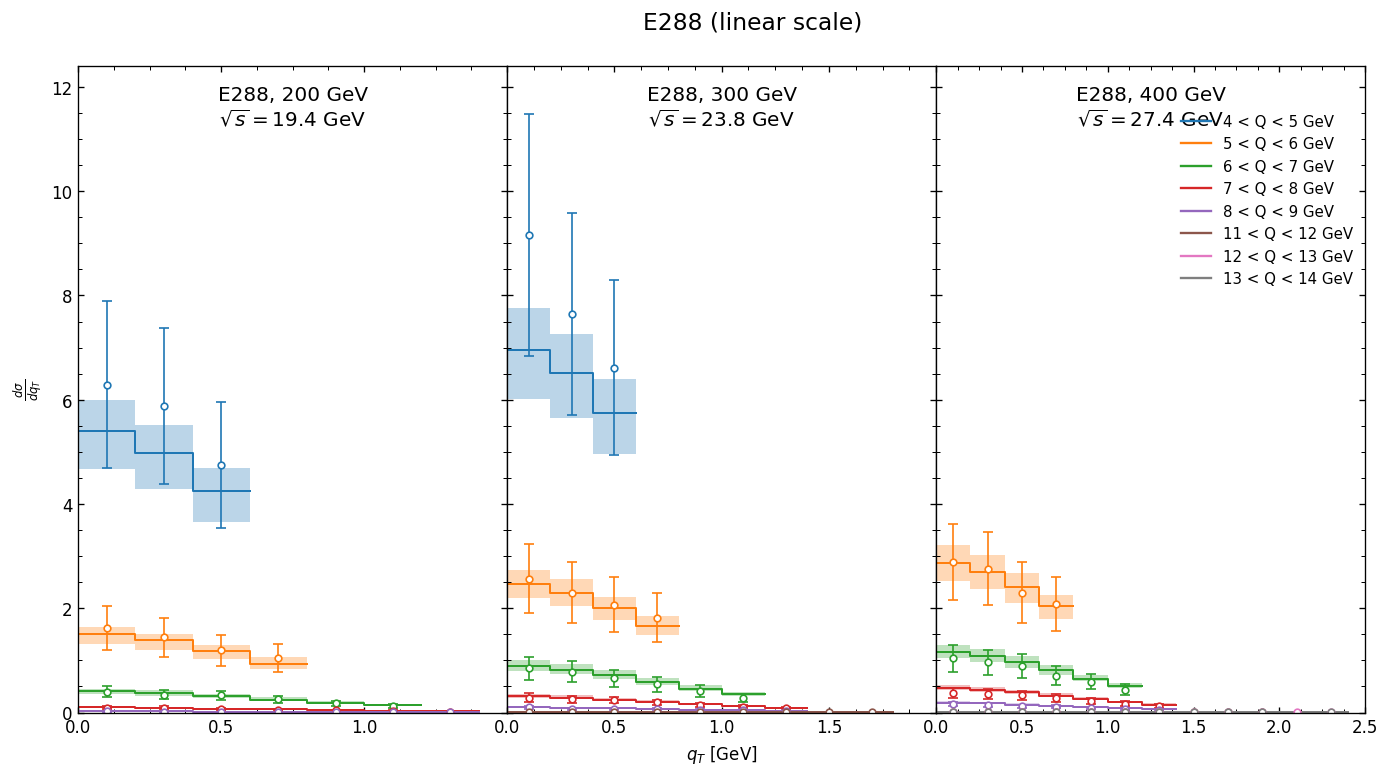

In [11]:
fig, axes = plt.subplots(1, len(beam_order), figsize=(15, 7), sharey=True)
if len(beam_order) == 1:
    axes = [axes]

fig.subplots_adjust(wspace=0.0, right=0.84, top=0.92, bottom=0.15)
fig.suptitle("E288 (linear scale)", fontsize=14, y=0.985)

global_y_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(
            np.nanmax(
                plots_list[fname]["data"].to_numpy(dtype=float)
                + plots_list[fname]["data_err"].to_numpy(dtype=float)
            )
        ),
    )
    for beam in beam_order
    for _, _, fname in e288_by_beam[beam]
)
global_y_max *= 1.08

for panel_idx, (ax, beam) in enumerate(zip(axes, beam_order)):
    panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e288_by_beam[beam])
    plot_q_bin_overlay(ax, e288_by_beam[beam], q_bin_colors)

    sqrt_s_value = fixed_target_sqrt_s(float(beam))
    ax.text(
        0.5,
        0.97,
        f"E288, {beam} GeV\n$\\sqrt{{s}} = {sqrt_s_value:.1f}\ \mathrm{{GeV}}$",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    if panel_idx == len(beam_order) // 2:
        ax.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax.set_xlabel("")
    _, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=panel_idx == len(beam_order) - 1)
    apply_dense_minor_ticks(ax, x_tick_step, y_scale="linear")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(False)
    ax.set_ylim(0.0, global_y_max)

    if panel_idx > 0:
        ax.tick_params(labelleft=False)

axes[0].set_ylabel(r"$\frac{d\sigma}{dq_T}$")

fig.legend(
    handles=build_q_bin_legend_handles(q_bin_order, q_bin_colors),
    loc="center left",
    bbox_to_anchor=(0.73, 0.76),
    frameon=False,
    fontsize=9,
)

plt.show()

Final Plots

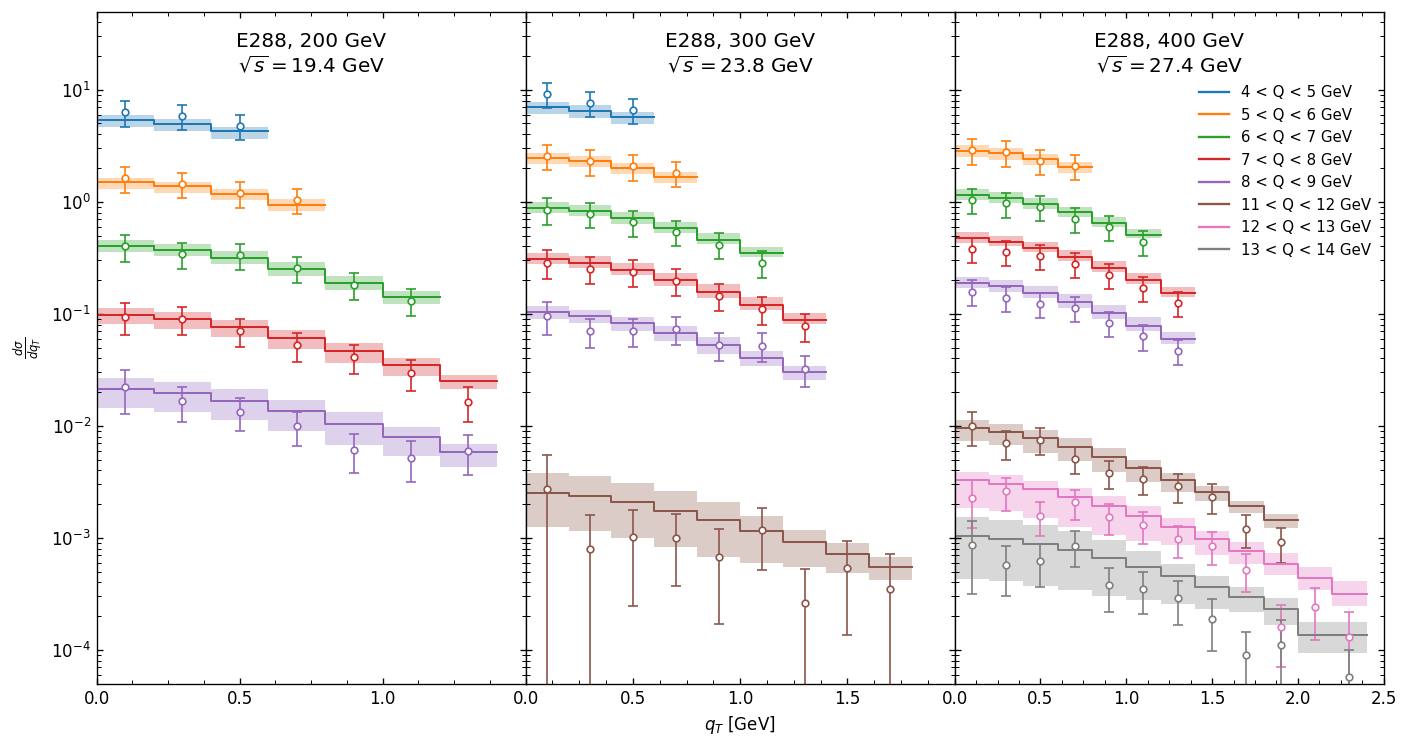

In [12]:


fig, axes = plt.subplots(1, len(beam_order), figsize=(15, 7), sharey=True)
if len(beam_order) == 1:
    axes = [axes]

fig.subplots_adjust(wspace=0.0, right=0.84, top=0.95, bottom=0.15)

for panel_idx, (ax, beam) in enumerate(zip(axes, beam_order)):
    panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e288_by_beam[beam])
    plot_q_bin_overlay(ax, e288_by_beam[beam], q_bin_colors)

    sqrt_s_value = fixed_target_sqrt_s(float(beam))
    ax.text(
        0.5,
        0.97,
        f"E288, {beam} GeV\n$\\sqrt{{s}} = {sqrt_s_value:.1f}\ \mathrm{{GeV}}$",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    if panel_idx == len(beam_order) // 2:
        ax.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax.set_xlabel("")
    ax.set_yscale("log")
    _, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=panel_idx == len(beam_order) - 1)
    apply_dense_minor_ticks(ax, x_tick_step, y_scale="log")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(False)

    if panel_idx > 0:
        ax.tick_params(labelleft=False)

axes[0].set_ylabel(r"$\frac{d\sigma}{dq_T}$")

fig.legend(
    handles=build_q_bin_legend_handles(q_bin_order, q_bin_colors),
    loc="center left",
    bbox_to_anchor=(0.73, 0.76),
    frameon=False,
    fontsize=9,
)

plt.ylim(5e-5, 50)
plt.show()


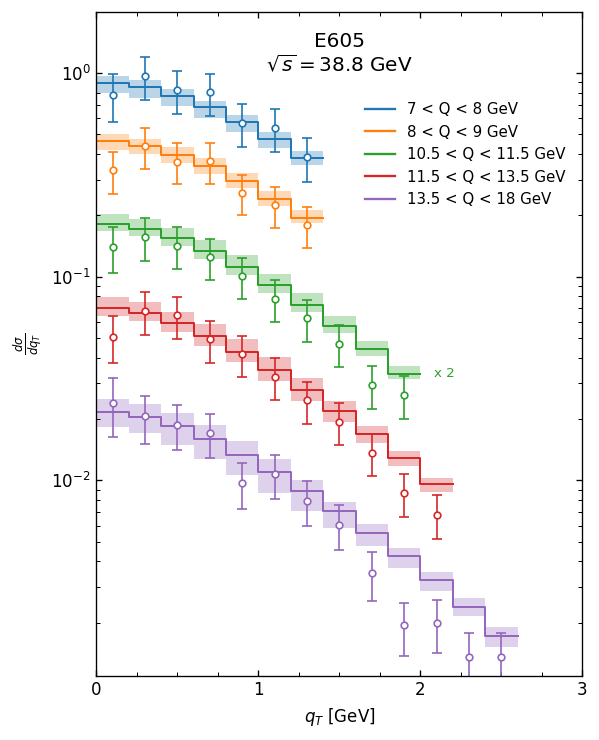

In [13]:
e605_files = [file for file in file_names if file.startswith("E605/") and file in plots_list]

if not e605_files:
    raise ValueError("No E605 datasets are available in the current selection")

e605_specs = []
for file in e605_files:
    q_lo, q_hi = parse_mass_bin_key(file, "E605")
    e605_specs.append((q_lo, q_hi, file))

e605_specs = sorted(e605_specs, key=lambda item: (item[0], item[1]))
e605_q_bins = [(q_lo, q_hi) for q_lo, q_hi, _ in e605_specs]
e605_scale_factors = {
    (10.5, 11.5): 2.0,
}
e605_colors = make_q_bin_colors(e605_q_bins)

fig, ax = plt.subplots(1, 1, figsize=(6, 7))
fig.subplots_adjust(right=0.8, top=0.95, bottom=0.16)

panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e605_specs)
plot_q_bin_overlay(ax, e605_specs, e605_colors, scale_factors=e605_scale_factors)

ax.text(
    0.5,
    0.97,
    f"E605\n$\\sqrt{{s}} = {fixed_target_sqrt_s(800.0):.1f}\ \mathrm{{GeV}}$",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)
ax.set_xlabel(r"$q_T$ [GeV]")
ax.set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ax.set_yscale("log")
_, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=True)
apply_dense_minor_ticks(ax, x_tick_step, y_scale="log")
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(False)

fig.legend(
    handles=build_q_bin_legend_handles(e605_q_bins, e605_colors, scale_factors=e605_scale_factors),
    loc="center left",
    bbox_to_anchor=(0.48, 0.78),
    frameon=False,
    fontsize=9,
)

plt.ylim(1.1e-3, 2)
plt.show()


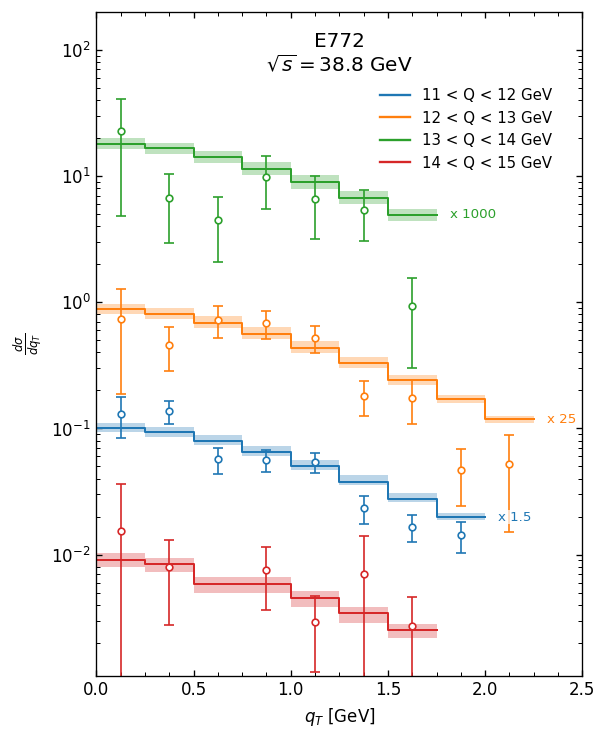

In [14]:
e772_files = [file for file in file_names if file.startswith("E772/") and file in plots_list]

if not e772_files:
    raise ValueError("No E772 datasets are available in the current selection")

e772_specs = []
for file in e772_files:
    q_lo, q_hi = parse_mass_bin_key(file, "E772")
    e772_specs.append((q_lo, q_hi, file))

e772_specs = sorted(e772_specs, key=lambda item: (item[0], item[1]))
e772_q_bins = [(q_lo, q_hi) for q_lo, q_hi, _ in e772_specs]
e772_scale_factors = {
    (11.0, 12.0): 1.5,
    (12.0, 13.0): 25.0,
    (13.0, 14.0): 1000.0,
}
e772_colors = make_q_bin_colors(e772_q_bins)

fig, ax = plt.subplots(1, 1, figsize=(6, 7))
fig.subplots_adjust(right=0.8, top=0.95, bottom=0.16)

panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e772_specs)
plot_q_bin_overlay(ax, e772_specs, e772_colors, scale_factors=e772_scale_factors)

ax.text(
    0.5,
    0.97,
    f"E772\n$\\sqrt{{s}} = {fixed_target_sqrt_s(800.0):.1f}\ \mathrm{{GeV}}$",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)
ax.set_xlabel(r"$q_T$ [GeV]")
ax.set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ax.set_yscale("log")
_, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=True)
apply_dense_minor_ticks(ax, x_tick_step, y_scale="log")
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(False)

fig.legend(
    handles=build_q_bin_legend_handles(e772_q_bins, e772_colors, scale_factors=e772_scale_factors),
    loc="center left",
    bbox_to_anchor=(0.5, 0.81),
    frameon=False,
    fontsize=9,
)

plt.ylim(1.1e-3, 200)
plt.show()


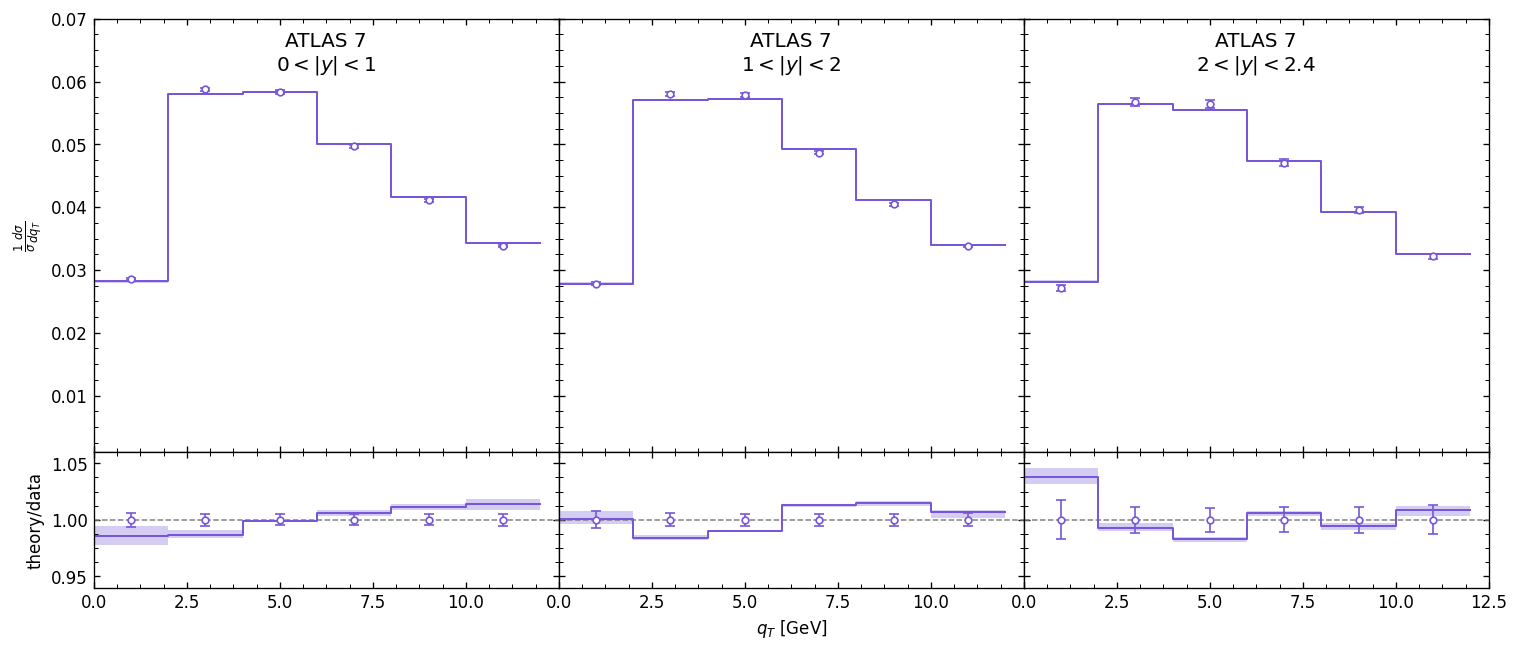

In [15]:
atlas7_files = [file for file in file_names if file.startswith("ATLAS_7/") and file in plots_list]

if not atlas7_files:
    raise ValueError("No ATLAS7 datasets are available in the current selection")

atlas7_specs = []
for file in atlas7_files:
    raw_df = data_list[file]
    y_lo = float(raw_df["y_min"].iloc[0])
    y_hi = float(raw_df["y_max"].iloc[0])
    atlas7_specs.append((y_lo, y_hi, file))

atlas7_specs = sorted(atlas7_specs, key=lambda item: (item[0], item[1]))
atlas7_colors = {(y_lo, y_hi): HIGH_ENERGY_COLOR for y_lo, y_hi, _ in atlas7_specs}


def choose_atlas7_tick_step(x_max, target_ticks=5):
    candidates = (1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


atlas7_main_max = max(
    max(
        np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float)),
        np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float)),
    )
    for _, _, fname in atlas7_specs
)
atlas7_ratio_half_span = max(
    max(
        abs(1.0 - np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float))),
        abs(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float)) - 1.0),
        np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float)),
    )
    for _, _, fname in atlas7_specs
)
atlas7_ratio_half_span = max(0.08, 1.15 * float(atlas7_ratio_half_span))

fig, axes = plt.subplots(
    2,
    len(atlas7_specs),
    figsize=(15, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
if len(atlas7_specs) == 1:
    axes = np.array([[axes[0]], [axes[1]]], dtype=object)

fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

for panel_idx, (y_lo, y_hi, fname) in enumerate(atlas7_specs):
    ax_main = axes[0, panel_idx]
    ax_ratio = axes[1, panel_idx]
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(y_lo, y_hi, fname)], atlas7_colors)
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        f"ATLAS 7\n${y_lo:g} < |y| < {y_hi:g}$",
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * atlas7_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(atlas7_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - atlas7_ratio_half_span, 1.0 + atlas7_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx == len(atlas7_specs) // 2:
        ax_ratio.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax_ratio.set_xlabel("")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
axes[1, 0].set_ylabel("theory/data")

# Optional shared y-limits across all three columns
# Examples:

atlas7_upper_ylim = (0.001, 0.07)
atlas7_ratio_ylim = (0.94, 1.06)

if atlas7_upper_ylim is not None:
    for ax in axes[0]:
        ax.set_ylim(*atlas7_upper_ylim)

if atlas7_ratio_ylim is not None:
    for ax in axes[1]:
        ax.set_ylim(*atlas7_ratio_ylim)

plt.show()


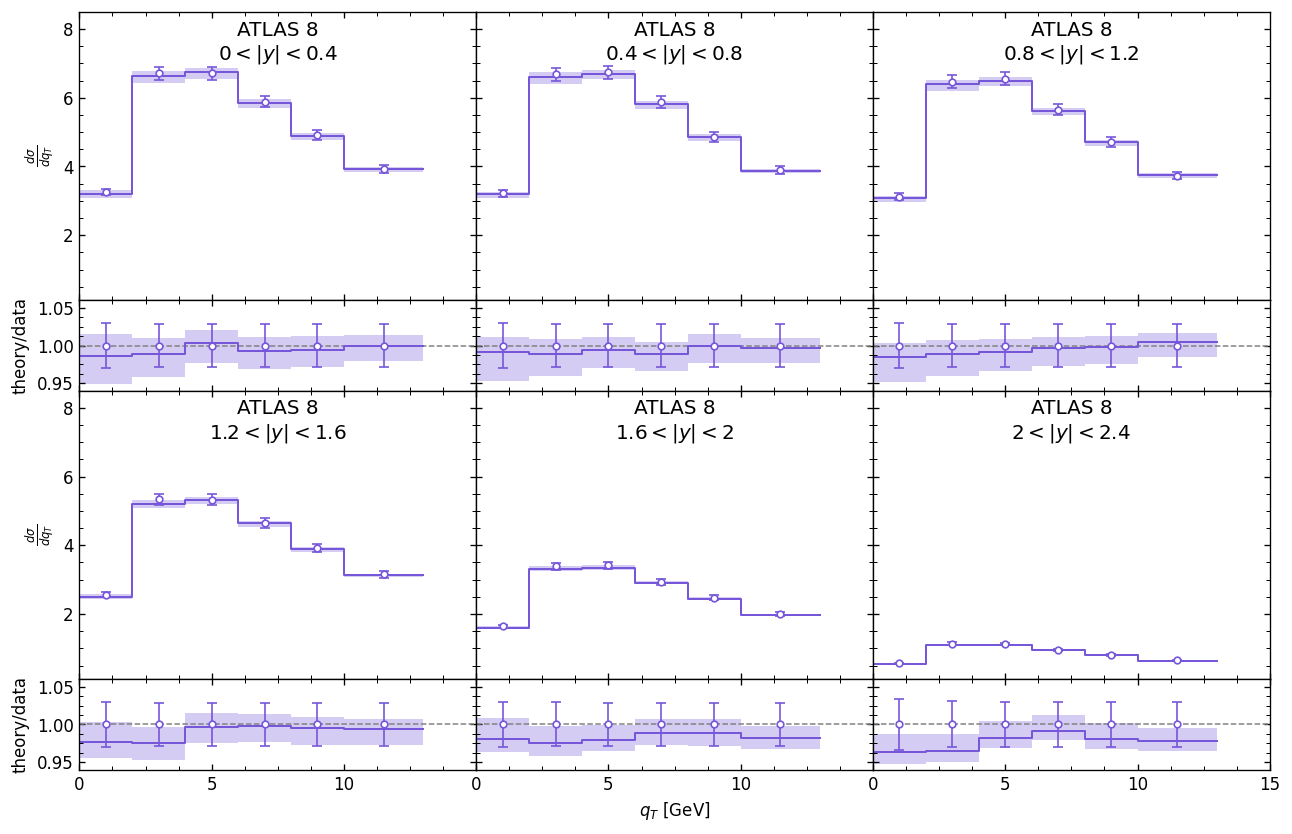

In [16]:
atlas8_files = [
    file
    for file in file_names
    if file.startswith("ATLAS_8/") and file in plots_list and "y" in Path(file).stem
]

if not atlas8_files:
    raise ValueError("No ATLAS8 rapidity-bin datasets are available in the current selection")

atlas8_specs = []
for file in atlas8_files:
    raw_df = data_list[file]
    y_lo = float(raw_df["y_min"].iloc[0])
    y_hi = float(raw_df["y_max"].iloc[0])
    atlas8_specs.append((y_lo, y_hi, file))

atlas8_specs = sorted(atlas8_specs, key=lambda item: (item[0], item[1]))
atlas8_colors = {(y_lo, y_hi): HIGH_ENERGY_COLOR for y_lo, y_hi, _ in atlas8_specs}


def choose_atlas8_tick_step(x_max, target_ticks=5):
    candidates = (1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


atlas8_main_max = max(
    max(
        np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float)),
        np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float)),
    )
    for _, _, fname in atlas8_specs
)
atlas8_ratio_half_span = max(
    max(
        abs(1.0 - np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float))),
        abs(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float)) - 1.0),
        np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float)),
    )
    for _, _, fname in atlas8_specs
)
atlas8_ratio_half_span = max(0.08, 1.15 * float(atlas8_ratio_half_span))

fig = plt.figure(figsize=(12.8, 8.2))
outer = fig.add_gridspec(2, 3, wspace=0.0, hspace=0.0)
main_axes = []
ratio_axes = []

for panel_idx, (y_lo, y_hi, fname) in enumerate(atlas8_specs):
    row_idx = panel_idx // 3
    col_idx = panel_idx % 3
    subgrid = outer[row_idx, col_idx].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.0)
    share_main = main_axes[0] if main_axes else None
    share_ratio = ratio_axes[0] if ratio_axes else None
    ax_main = fig.add_subplot(subgrid[0], sharey=share_main)
    ax_ratio = fig.add_subplot(subgrid[1], sharex=ax_main, sharey=share_ratio)
    main_axes.append(ax_main)
    ratio_axes.append(ax_ratio)

    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas8_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(y_lo, y_hi, fname)], atlas8_colors)
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        f"ATLAS 8\n${y_lo:g} < |y| < {y_hi:g}$",
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * atlas8_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(atlas8_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - atlas8_ratio_half_span, 1.0 + atlas8_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx in (1, 4):
        ax_ratio.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax_ratio.set_xlabel("")

    if col_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)
    if row_idx == 0:
        ax_ratio.tick_params(labelbottom=False)

for idx in (0, 3):
    main_axes[idx].set_ylabel(r"$\frac{d\sigma}{dq_T}$")
    ratio_axes[idx].set_ylabel("theory/data")

# Optional shared y-limits across all ATLAS8 columns

atlas8_upper_ylim = (0.1,8.5)
atlas8_ratio_ylim = (0.94,1.06)

if atlas8_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*atlas8_upper_ylim)

if atlas8_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*atlas8_ratio_ylim)

plt.show()


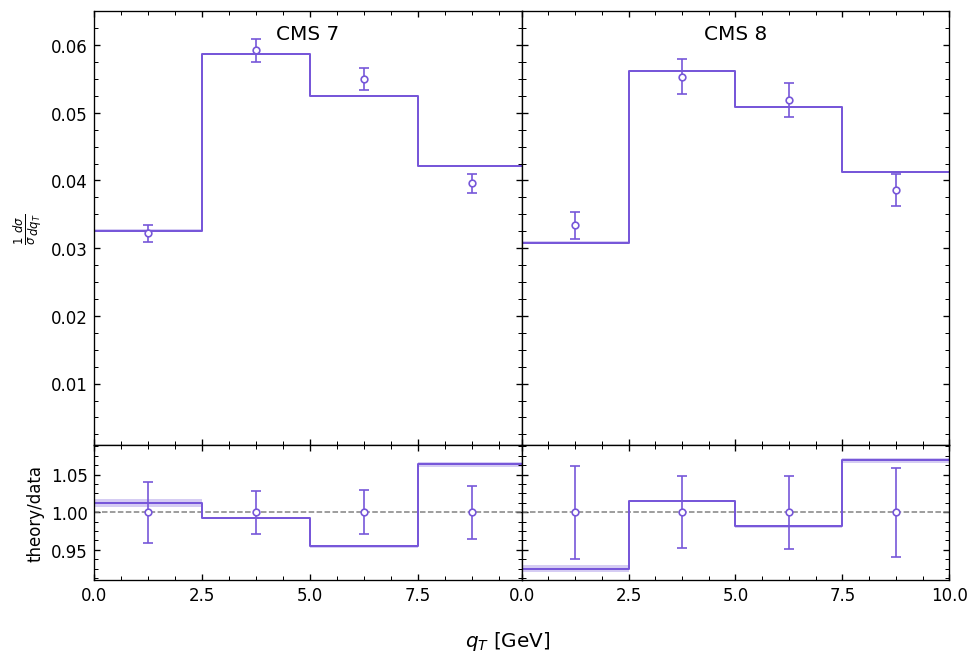

In [17]:
cms7_files = [file for file in file_names if file.startswith("CMS_7/") and file in plots_list]
cms8_files = [file for file in file_names if file.startswith("CMS_8/") and file in plots_list]

if not cms7_files:
    raise ValueError("No CMS7 datasets are available in the current selection")
if not cms8_files:
    raise ValueError("No CMS8 datasets are available in the current selection")

cms_specs = [("CMS 7", cms7_files[0]), ("CMS 8", cms8_files[0])]

cms_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in cms_specs
)
cms_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in cms_specs
)
cms_ratio_half_span = max(0.08, 1.15 * cms_ratio_half_span)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9.2, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, 0], axes[0, 1]]
ratio_axes = [axes[1, 0], axes[1, 1]]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(cms_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 2.1, fname)], {(0.0, 2.1): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * cms_main_max)
    ax_main.set_xlim(0.0, x_upper-0.1)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper-0.1)
    if panel_idx < len(cms_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - cms_ratio_half_span, 1.0 + cms_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
# cms78_upper_ylim = (0.0, 0.07)
# cms78_ratio_ylim = (0.94, 1.06)
cms78_upper_ylim = (0.001, 0.065)
cms78_ratio_ylim = (0.91, 1.09)

if cms78_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*cms78_upper_ylim)

if cms78_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*cms78_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


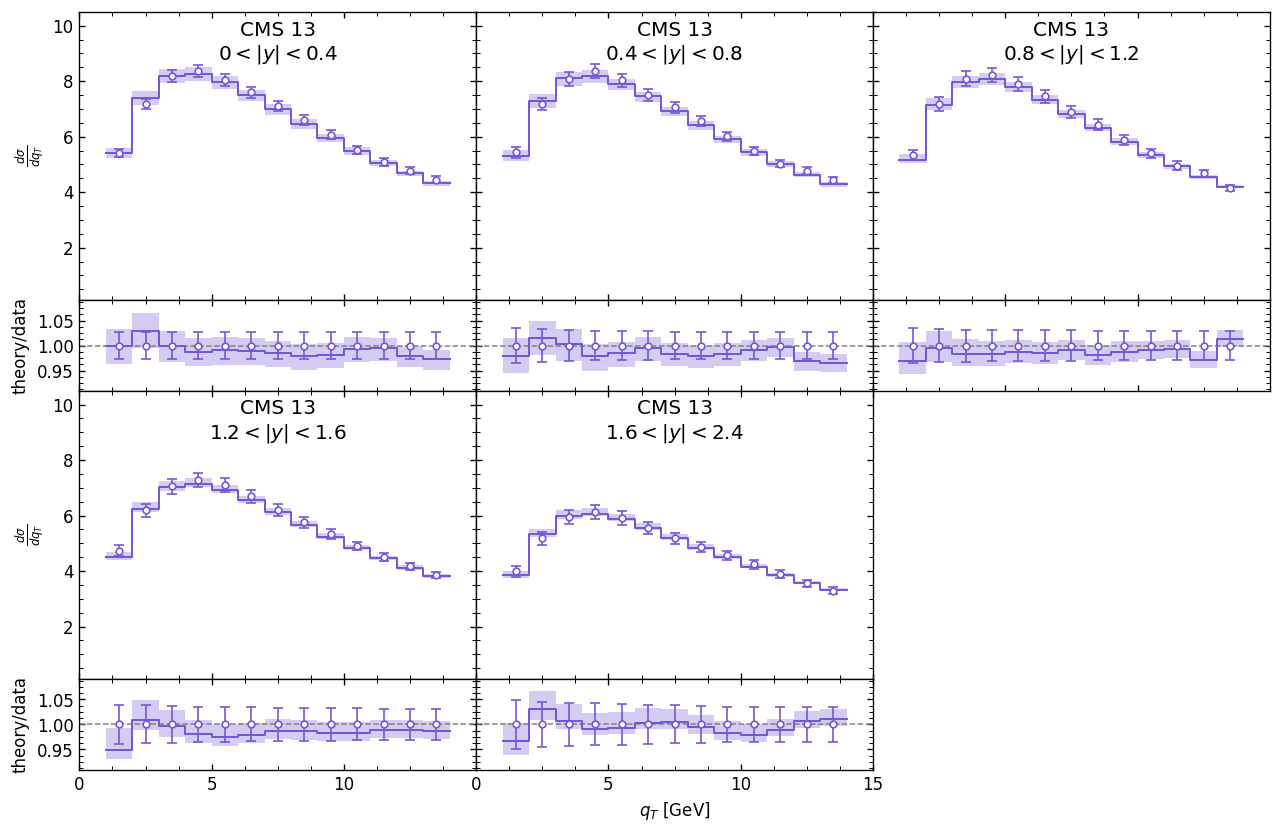

In [18]:
cms13_files = [
    file
    for file in file_names
    if file.startswith("CMS_13/") and file in plots_list and "y" in Path(file).stem
]

if not cms13_files:
    raise ValueError("No CMS13 rapidity-bin datasets are available in the current selection")

cms13_specs = []
for file in cms13_files:
    raw_df = data_list[file]
    y_lo = float(raw_df["y_min"].iloc[0])
    y_hi = float(raw_df["y_max"].iloc[0])
    cms13_specs.append((y_lo, y_hi, file))

cms13_specs = sorted(cms13_specs, key=lambda item: (item[0], item[1]))
cms13_colors = {(y_lo, y_hi): HIGH_ENERGY_COLOR for y_lo, y_hi, _ in cms13_specs}


def choose_cms13_tick_step(x_max, target_ticks=5):
    candidates = (1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


cms13_main_max = max(
    max(
        np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float)),
        np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float)),
    )
    for _, _, fname in cms13_specs
)
cms13_ratio_half_span = max(
    max(
        abs(1.0 - np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float))),
        abs(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float)) - 1.0),
        np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float)),
    )
    for _, _, fname in cms13_specs
)
cms13_ratio_half_span = max(0.08, 1.15 * float(cms13_ratio_half_span))

fig = plt.figure(figsize=(12.8, 8.2))
outer = fig.add_gridspec(2, 3, wspace=0.0, hspace=0.0)
main_axes = []
ratio_axes = []

for panel_idx, (y_lo, y_hi, fname) in enumerate(cms13_specs):
    row_idx = panel_idx // 3
    col_idx = panel_idx % 3
    subgrid = outer[row_idx, col_idx].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.0)
    share_main = main_axes[0] if main_axes else None
    share_ratio = ratio_axes[0] if ratio_axes else None
    ax_main = fig.add_subplot(subgrid[0], sharey=share_main)
    ax_ratio = fig.add_subplot(subgrid[1], sharex=ax_main, sharey=share_ratio)
    main_axes.append(ax_main)
    ratio_axes.append(ax_ratio)

    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_cms13_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(y_lo, y_hi, fname)], cms13_colors)
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        f"CMS 13\n${y_lo:g} < |y| < {y_hi:g}$",
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * cms13_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(cms13_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - cms13_ratio_half_span, 1.0 + cms13_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx in (1, 4):
        ax_ratio.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax_ratio.set_xlabel("")

    if col_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)
    if row_idx == 0:
        ax_ratio.tick_params(labelbottom=False)

# hide the unused 6th slot
empty_subgrid = outer[1, 2].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.0)
fig.add_subplot(empty_subgrid[0]).axis("off")
fig.add_subplot(empty_subgrid[1]).axis("off")

for idx in (0, 3):
    main_axes[idx].set_ylabel(r"$\frac{d\sigma}{dq_T}$")
    ratio_axes[idx].set_ylabel("theory/data")

# Optional shared y-limits across all CMS13 columns
# cms13_upper_ylim = (0.1,10)
# cms13_ratio_ylim = (0.88, 1.12)
cms13_upper_ylim = (0.1,10.5)
cms13_ratio_ylim = (0.91, 1.09)

if cms13_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*cms13_upper_ylim)

if cms13_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*cms13_ratio_ylim)

plt.show()


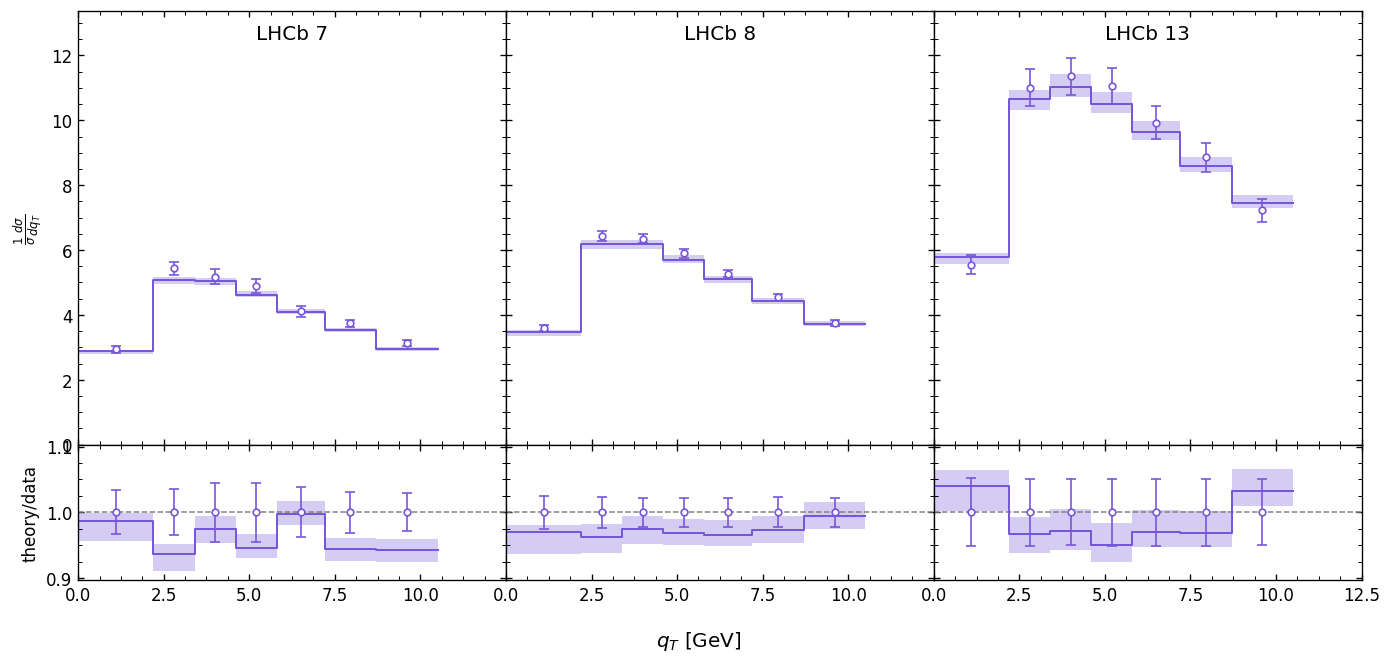

In [ ]:
lhcb7_files = [file for file in file_names if file.startswith("LHCb_7/") and file in plots_list]
lhcb8_files = [file for file in file_names if file.startswith("LHCb_8/") and file in plots_list]
lhcb13_files = [file for file in file_names if file.startswith("LHCb_13/") and file in plots_list]

if not lhcb7_files:
    raise ValueError("No LHCb 7 datasets are available in the current selection")
if not lhcb8_files:
    raise ValueError("No LHCb 8 datasets are available in the current selection")
if not lhcb13_files:
    raise ValueError("No LHCb 13 datasets are available in the current selection")

lhcb_specs = [("LHCb 7", lhcb7_files[0]), ("LHCb 8", lhcb8_files[0]), ("LHCb 13", lhcb13_files[0])]

lhcb_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in lhcb_specs
)
lhcb_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in lhcb_specs
)
lhcb_ratio_half_span = max(0.08, 1.15 * lhcb_ratio_half_span)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13.8, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, 0], axes[0, 1], axes[0, 2]]
ratio_axes = [axes[1, 0], axes[1, 1], axes[1, 2]]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(lhcb_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 1.0, fname)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * lhcb_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(lhcb_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - lhcb_ratio_half_span, 1.0 + lhcb_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
lhcb_upper_ylim = None
lhcb_ratio_ylim = None

if lhcb_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*lhcb_upper_ylim)

if lhcb_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*lhcb_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


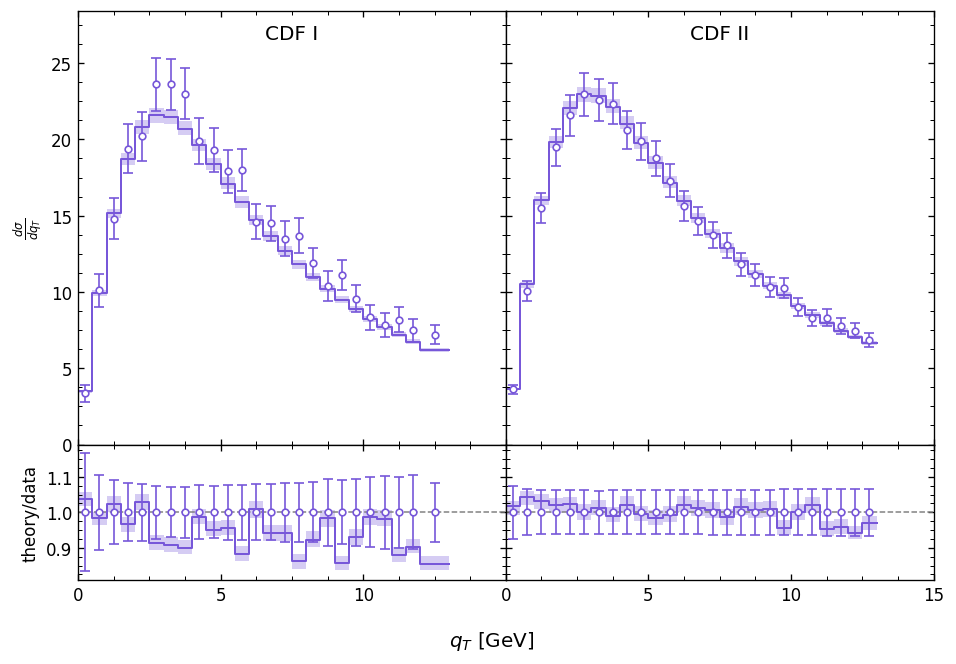

In [20]:
cdf1_files = [file for file in file_names if file.startswith("CDF_I/") and file in plots_list]
cdf2_files = [file for file in file_names if file.startswith("CDF_II/") and file in plots_list]

if not cdf1_files:
    raise ValueError("No CDF I datasets are available in the current selection")
if not cdf2_files:
    raise ValueError("No CDF II datasets are available in the current selection")

cdf_specs = [("CDF I", cdf1_files[0]), ("CDF II", cdf2_files[0])]

cdf_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in cdf_specs
)
cdf_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in cdf_specs
)
cdf_ratio_half_span = max(0.08, 1.15 * cdf_ratio_half_span)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9.2, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, 0], axes[0, 1]]
ratio_axes = [axes[1, 0], axes[1, 1]]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(cdf_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 1.0, fname)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * cdf_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(cdf_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - cdf_ratio_half_span, 1.0 + cdf_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
cdf_upper_ylim = (0.1, 39)
cdf_ratio_ylim = (0.81, 1.19)
cdf_upper_ylim = None
cdf_ratio_ylim = None

if cdf_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*cdf_upper_ylim)

if cdf_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*cdf_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


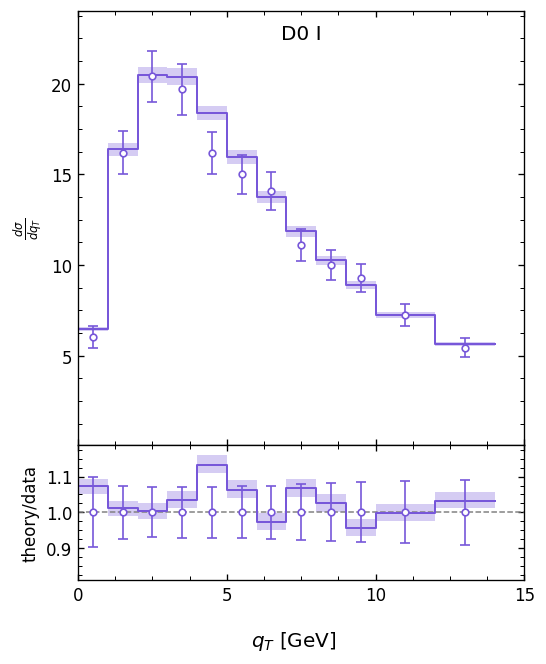

In [21]:
d0i_files = [file for file in file_names if file.startswith("D0_I/") and file in plots_list]

if not d0i_files:
    raise ValueError("No D0 I datasets are available in the current selection")

d0i_file = d0i_files[0]
d0i_panel_x_max = float(data_list[d0i_file]["qT_max"].max())
d0i_main_max = max(
    float(np.nanmax(plots_list[d0i_file]["pred_hi"].to_numpy(dtype=float))),
    float(np.nanmax((plots_list[d0i_file]["data"] + plots_list[d0i_file]["data_err"]).to_numpy(dtype=float))),
)
d0i_ratio_half_span = max(
    abs(1.0 - float(np.nanmin(plots_list[d0i_file]["ratio_lo"].to_numpy(dtype=float)))),
    abs(float(np.nanmax(plots_list[d0i_file]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
    float(np.nanmax(plots_list[d0i_file]["ratio_err"].to_numpy(dtype=float))),
)
d0i_ratio_half_span = max(0.08, 1.15 * d0i_ratio_half_span)
d0i_x_tick_step = choose_atlas7_tick_step(d0i_panel_x_max)
d0i_x_upper = d0i_x_tick_step * np.ceil(d0i_panel_x_max / d0i_x_tick_step)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(4.8, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
ax_main, ax_ratio = axes
fig.subplots_adjust(hspace=0.0, top=0.95, bottom=0.16)

plot_q_bin_overlay(ax_main, [(0.0, 1.0, d0i_file)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
plot_ratio_panel(ax_ratio, d0i_file, color=HIGH_ENERGY_COLOR)

ax_main.text(
    0.5,
    0.97,
    "D0 I",
    transform=ax_main.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)
ax_main.set_ylim(0.0, 1.12 * d0i_main_max)
ax_main.set_xlim(0.0, d0i_x_upper)
ax_main.tick_params(which="both", direction="in", top=True, right=True)
ax_main.grid(False)
ax_main.tick_params(labelbottom=False)
ax_main.xaxis.set_minor_locator(MultipleLocator(float(d0i_x_tick_step) / 4.0))
ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

ax_ratio.set_xlim(0.0, d0i_x_upper)
ax_ratio.set_xticks(np.arange(0.0, d0i_x_upper + 0.5 * d0i_x_tick_step, d0i_x_tick_step))
ax_ratio.set_ylim(1.0 - d0i_ratio_half_span, 1.0 + d0i_ratio_half_span)
ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
ax_ratio.grid(False)
apply_dense_minor_ticks(ax_ratio, d0i_x_tick_step, y_scale="linear")

ax_main.set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ax_ratio.set_ylabel("theory/data")

# Optional shared y-limits
d0i_upper_ylim = (0.1, 24)
d0i_ratio_ylim = (0.81, 1.19)

if d0i_upper_ylim is not None:
    ax_main.set_ylim(*d0i_upper_ylim)

if d0i_ratio_ylim is not None:
    ax_ratio.set_ylim(*d0i_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


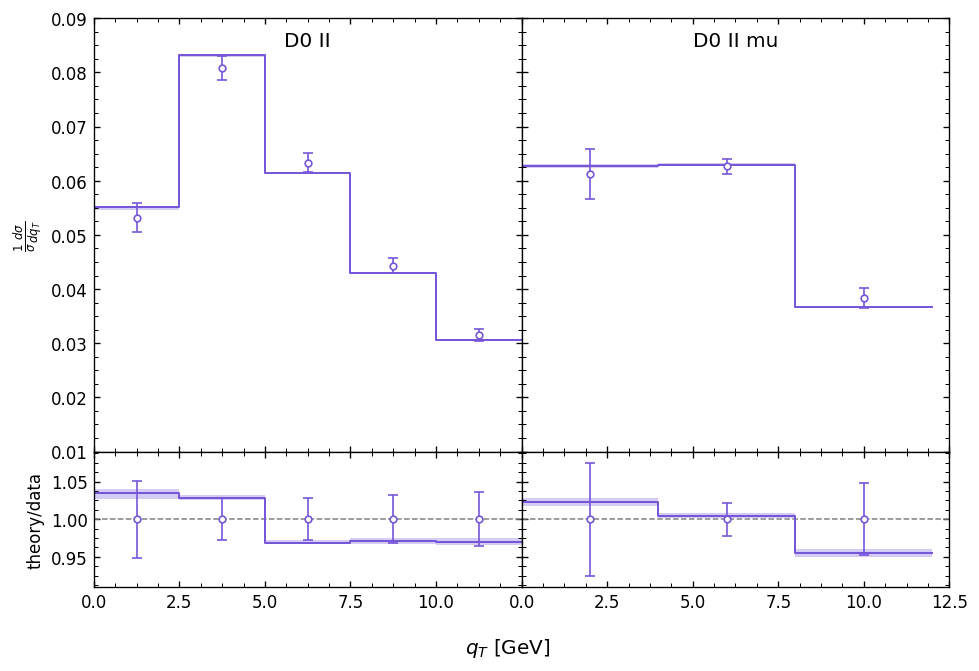

In [22]:
d0ii_specs = []
for title, prefix in [("D0 II", "D0_II/"), ("D0 II mu", "D0_II_mu/")]:
    files = [file for file in file_names if file.startswith(prefix) and file in plots_list]
    if not files:
        continue
    d0ii_specs.append((title, files[0]))

if not d0ii_specs:
    raise ValueError("No D0 II datasets are available in the current selection")

d0ii_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in d0ii_specs
)
d0ii_ratio_half_span = max(0.08, 1.15 * d0ii_ratio_half_span)
d0ii_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in d0ii_specs
)

fig, axes = plt.subplots(
    2,
    len(d0ii_specs),
    figsize=(4.6 * len(d0ii_specs), 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
if len(d0ii_specs) == 1:
    axes = np.array([[axes[0]], [axes[1]]], dtype=object)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, i] for i in range(len(d0ii_specs))]
ratio_axes = [axes[1, i] for i in range(len(d0ii_specs))]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(d0ii_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 1.0, fname)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * d0ii_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(d0ii_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - d0ii_ratio_half_span, 1.0 + d0ii_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
d0ii_upper_ylim = (0.01, 0.09)
d0ii_ratio_ylim = (0.91, 1.09)

if d0ii_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*d0ii_upper_ylim)

if d0ii_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*d0ii_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


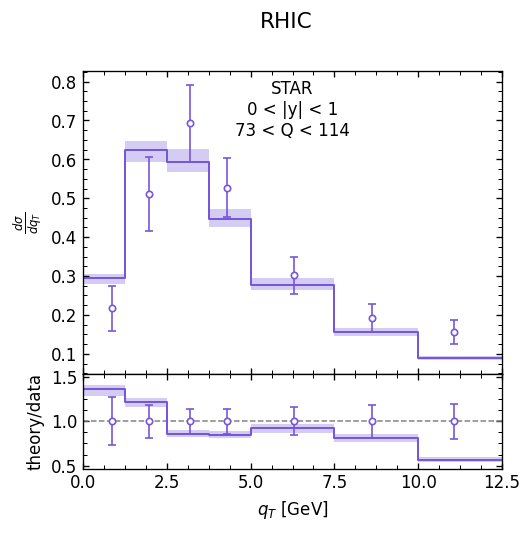

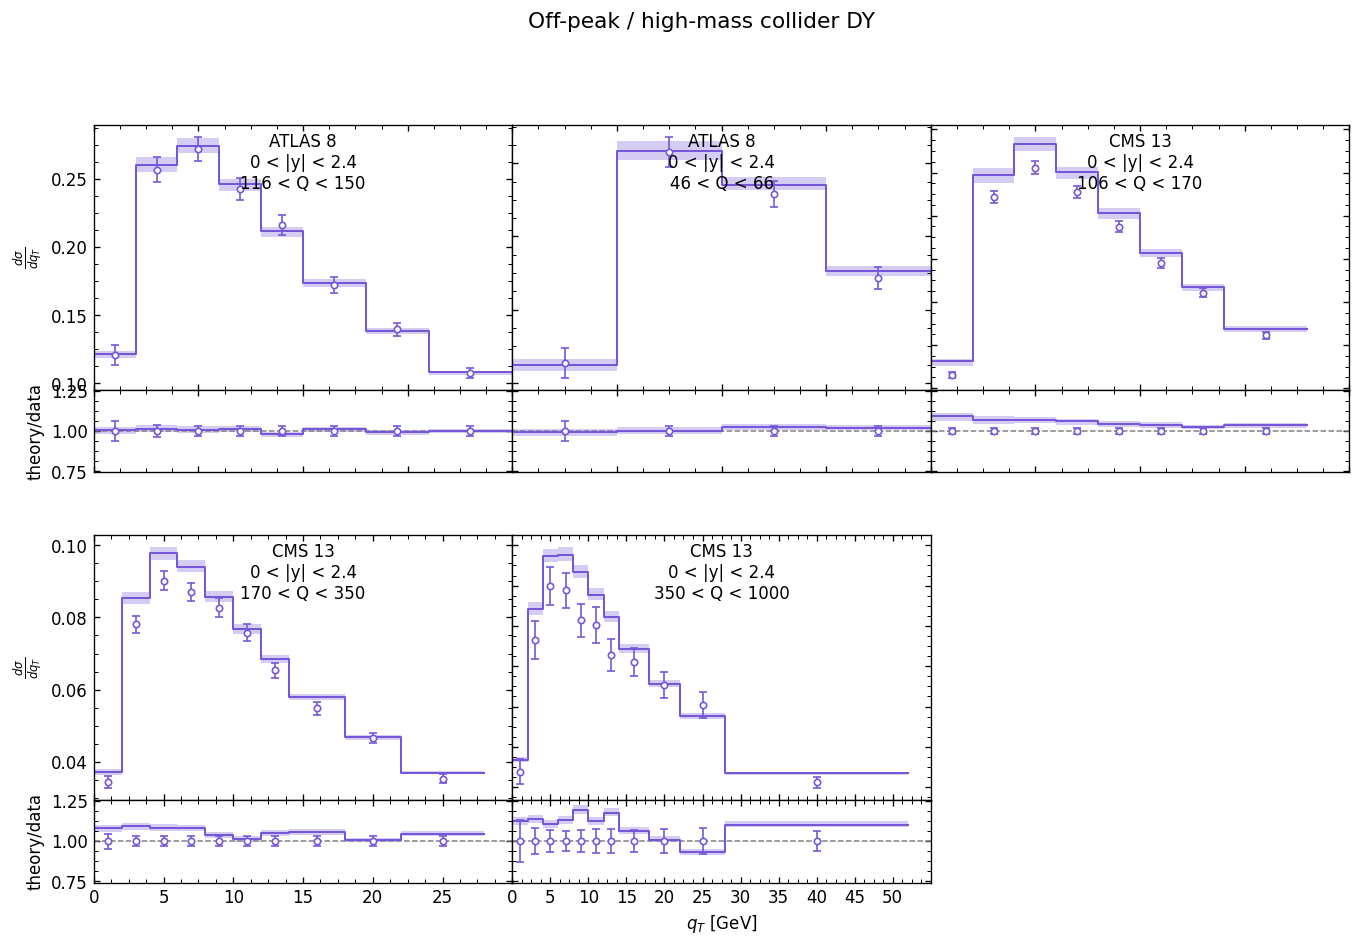

In [23]:
def overview_step_xy(x_min, x_max, values):
    edges = np.concatenate(([float(x_min[0])], np.asarray(x_max, dtype=float)))
    x_curve = np.repeat(edges, 2)[1:-1]
    y_curve = np.repeat(np.asarray(values, dtype=float), 2)
    return x_curve, y_curve


def overview_tick_step(x_max, target_ticks=5):
    candidates = (0.5, 1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


def overview_apply_minor_ticks(ax, x_tick_step, y_scale="linear"):
    ax.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    if y_scale == "log":
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
    else:
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)


def overview_is_normalized(file):
    raw_df = data_list[file]
    if "observable" not in raw_df.columns:
        return False
    observable = str(raw_df["observable"].iloc[0])
    return observable.startswith("1/")


def overview_ylabel(file):
    if overview_is_normalized(file):
        return r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$"
    return r"$\frac{d\sigma}{dq_T}$"


def overview_color(file):
    high_energy_prefixes = (
        "ATLAS_7/",
        "ATLAS_8/",
        "CMS_7/",
        "CMS_8/",
        "CMS_13/",
        "LHCb_7/",
        "LHCb_8/",
        "LHCb_13/",
        "STAR/",
        "PHENIX/",
        "CDF_I/",
        "CDF_II/",
        "D0_I/",
        "D0_II/",
        "D0_II_mu/",
    )
    if file.startswith(high_energy_prefixes):
        return "#7757D9"
    return "#295C9B"


def overview_title(file):
    experiment, stem_with_ext = file.split("/", 1)
    stem = Path(stem_with_ext).stem
    raw_df = data_list[file]
    label_map = {
        "ATLAS_7": "ATLAS 7",
        "ATLAS_8": "ATLAS 8",
        "CMS_7": "CMS 7",
        "CMS_8": "CMS 8",
        "CMS_13": "CMS 13",
        "LHCb_7": "LHCb 7",
        "LHCb_8": "LHCb 8",
        "LHCb_13": "LHCb 13",
        "CDF_I": "CDF I",
        "CDF_II": "CDF II",
        "D0_I": "D0 I",
        "D0_II": "D0 II",
        "D0_II_mu": "D0 II mu",
        "STAR": "STAR",
        "PHENIX": "PHENIX",
        "E288": "E288",
        "E605": "E605",
        "E772": "E772",
    }
    parts = [label_map.get(experiment, experiment.replace("_", " "))]
    if experiment == "E288":
        match = re.match(r"E228-(\d+)-(\d+(?:\.\d+)?)Q(\d+(?:\.\d+)?)$", stem)
        if match is not None:
            parts.append(f"{int(match.group(1))} GeV")
            parts.append(f"{float(match.group(2)):g} < Q < {float(match.group(3)):g}")
            return "\n".join(parts)
    if "y_min" in raw_df.columns and "y_max" in raw_df.columns:
        y_lo = float(raw_df["y_min"].iloc[0])
        y_hi = float(raw_df["y_max"].iloc[0])
        if y_hi > y_lo:
            parts.append(f"{y_lo:g} < |y| < {y_hi:g}")
    if "Q_min" in raw_df.columns and "Q_max" in raw_df.columns:
        q_lo = float(raw_df["Q_min"].iloc[0])
        q_hi = float(raw_df["Q_max"].iloc[0])
        if q_hi > q_lo and "y" not in stem:
            parts.append(f"{q_lo:g} < Q < {q_hi:g}")
    return "\n".join(parts)


group_specs = [
    (
        "RHIC",
        lambda file: file.startswith(("STAR/", "PHENIX/")),
    ),
    (
        "Off-peak / high-mass collider DY",
        lambda file: (
            (file.startswith("ATLAS_8/") and "Q" in Path(file).stem)
            or (file.startswith("CMS_13/") and "Q" in Path(file).stem)
        ),
    ),
]


for group_name, selector in group_specs:
    grouped_files = [file for file in file_names if file in plots_list and selector(file)]
    if not grouped_files:
        continue

    grouped_files = sorted(grouped_files)
    ncols = min(3, len(grouped_files))
    nrows = int(np.ceil(len(grouped_files) / ncols))
    fig = plt.figure(figsize=(4.5 * ncols, 3.9 * nrows + 0.4))
    outer = fig.add_gridspec(nrows, ncols, wspace=0.0, hspace=0.18)
    fig.suptitle(group_name, fontsize=13, y=0.995)

    ratio_half_span = max(
        max(
            abs(1.0 - float(np.nanmin(plots_list[file]["ratio_lo"].to_numpy(dtype=float)))),
            abs(float(np.nanmax(plots_list[file]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
            float(np.nanmax(plots_list[file]["ratio_err"].to_numpy(dtype=float))),
        )
        for file in grouped_files
    )
    ratio_half_span = max(0.08, 1.15 * ratio_half_span)

    panel_axes = []
    for panel_idx, file in enumerate(grouped_files):
        row_idx = panel_idx // ncols
        col_idx = panel_idx % ncols
        subgrid = outer[row_idx, col_idx].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.0)
        ax_main = fig.add_subplot(subgrid[0])
        ax_ratio = fig.add_subplot(subgrid[1], sharex=ax_main)
        panel_axes.append((ax_main, ax_ratio))

        raw_df = data_list[file]
        d = plots_list[file]
        qT = d["qT"].to_numpy(dtype=float)
        qT_min = raw_df["qT_min"].to_numpy(dtype=float)
        qT_max = raw_df["qT_max"].to_numpy(dtype=float)
        data_vals = d["data"].to_numpy(dtype=float)
        data_err = d["data_err"].to_numpy(dtype=float)
        central = d["central"].to_numpy(dtype=float)
        pred_lo = d["pred_lo"].to_numpy(dtype=float)
        pred_hi = d["pred_hi"].to_numpy(dtype=float)
        central_ratio = d["central_ratio"].to_numpy(dtype=float)
        ratio_lo = d["ratio_lo"].to_numpy(dtype=float)
        ratio_hi = d["ratio_hi"].to_numpy(dtype=float)
        ratio_err = d["ratio_err"].to_numpy(dtype=float)
        color = overview_color(file)

        x_curve, central_curve = overview_step_xy(qT_min, qT_max, central)
        _, lo_curve = overview_step_xy(qT_min, qT_max, pred_lo)
        _, hi_curve = overview_step_xy(qT_min, qT_max, pred_hi)
        _, central_ratio_curve = overview_step_xy(qT_min, qT_max, central_ratio)
        _, ratio_lo_curve = overview_step_xy(qT_min, qT_max, ratio_lo)
        _, ratio_hi_curve = overview_step_xy(qT_min, qT_max, ratio_hi)

        ax_main.errorbar(
            qT,
            data_vals,
            yerr=data_err,
            fmt="o",
            ms=3.8,
            elinewidth=1.0,
            capsize=2.5,
            color=color,
            mec=color,
            mfc="white",
        )
        ax_main.fill_between(x_curve, lo_curve, hi_curve, color=color, alpha=0.3, linewidth=0.0)
        ax_main.plot(x_curve, central_curve, color=color, linewidth=1.2, drawstyle="steps-mid")

        ax_ratio.axhline(1.0, color="0.5", linewidth=0.9, linestyle="--")
        ax_ratio.errorbar(
            qT,
            np.ones_like(qT),
            yerr=ratio_err,
            fmt="o",
            ms=3.8,
            elinewidth=1.0,
            capsize=2.5,
            color=color,
            mec=color,
            mfc="white",
        )
        ax_ratio.fill_between(x_curve, ratio_lo_curve, ratio_hi_curve, color=color, alpha=0.3, linewidth=0.0)
        ax_ratio.plot(x_curve, central_ratio_curve, color=color, linewidth=1.2, drawstyle="steps-mid")

        panel_x_max = float(qT_max.max())
        x_tick_step = overview_tick_step(panel_x_max)
        x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)
        ax_main.set_xlim(0.0, x_upper)
        ax_ratio.set_xlim(0.0, x_upper)
        if col_idx < ncols - 1:
            x_ticks = np.arange(0.0, x_upper, x_tick_step)
        else:
            x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
        ax_ratio.set_xticks(x_ticks)
        overview_apply_minor_ticks(ax_main, x_tick_step, y_scale="linear")
        overview_apply_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")
        ax_main.tick_params(which="both", direction="in", top=True, right=True)
        ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
        ax_main.grid(False)
        ax_ratio.grid(False)
        ax_main.tick_params(labelbottom=False)
        ax_ratio.set_ylim(1.0 - ratio_half_span, 1.0 + ratio_half_span)

        ax_main.text(
            0.5,
            0.97,
            overview_title(file),
            transform=ax_main.transAxes,
            ha="center",
            va="top",
            fontsize=10,
        )

        if row_idx == nrows - 1 and col_idx == ncols // 2:
            ax_ratio.set_xlabel(r"$q_T$ [GeV]")
        else:
            ax_ratio.set_xlabel("")
        if row_idx < nrows - 1:
            ax_ratio.tick_params(labelbottom=False)

        if col_idx > 0:
            ax_main.tick_params(labelleft=False)
            ax_ratio.tick_params(labelleft=False)
        elif overview_is_normalized(file):
            ax_main.set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
            ax_ratio.set_ylabel("theory/data")
        else:
            ax_main.set_ylabel(r"$\frac{d\sigma}{dq_T}$")
            ax_ratio.set_ylabel("theory/data")

    total_slots = nrows * ncols
    for empty_idx in range(len(grouped_files), total_slots):
        row_idx = empty_idx // ncols
        col_idx = empty_idx % ncols
        ax_empty = fig.add_subplot(outer[row_idx, col_idx])
        ax_empty.axis("off")

    plt.show()